# Top-NMF: Appendix 2

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import make_interp_spline

from TopNMF import *

device = 'cpu'

# Generate Synthetic Signals

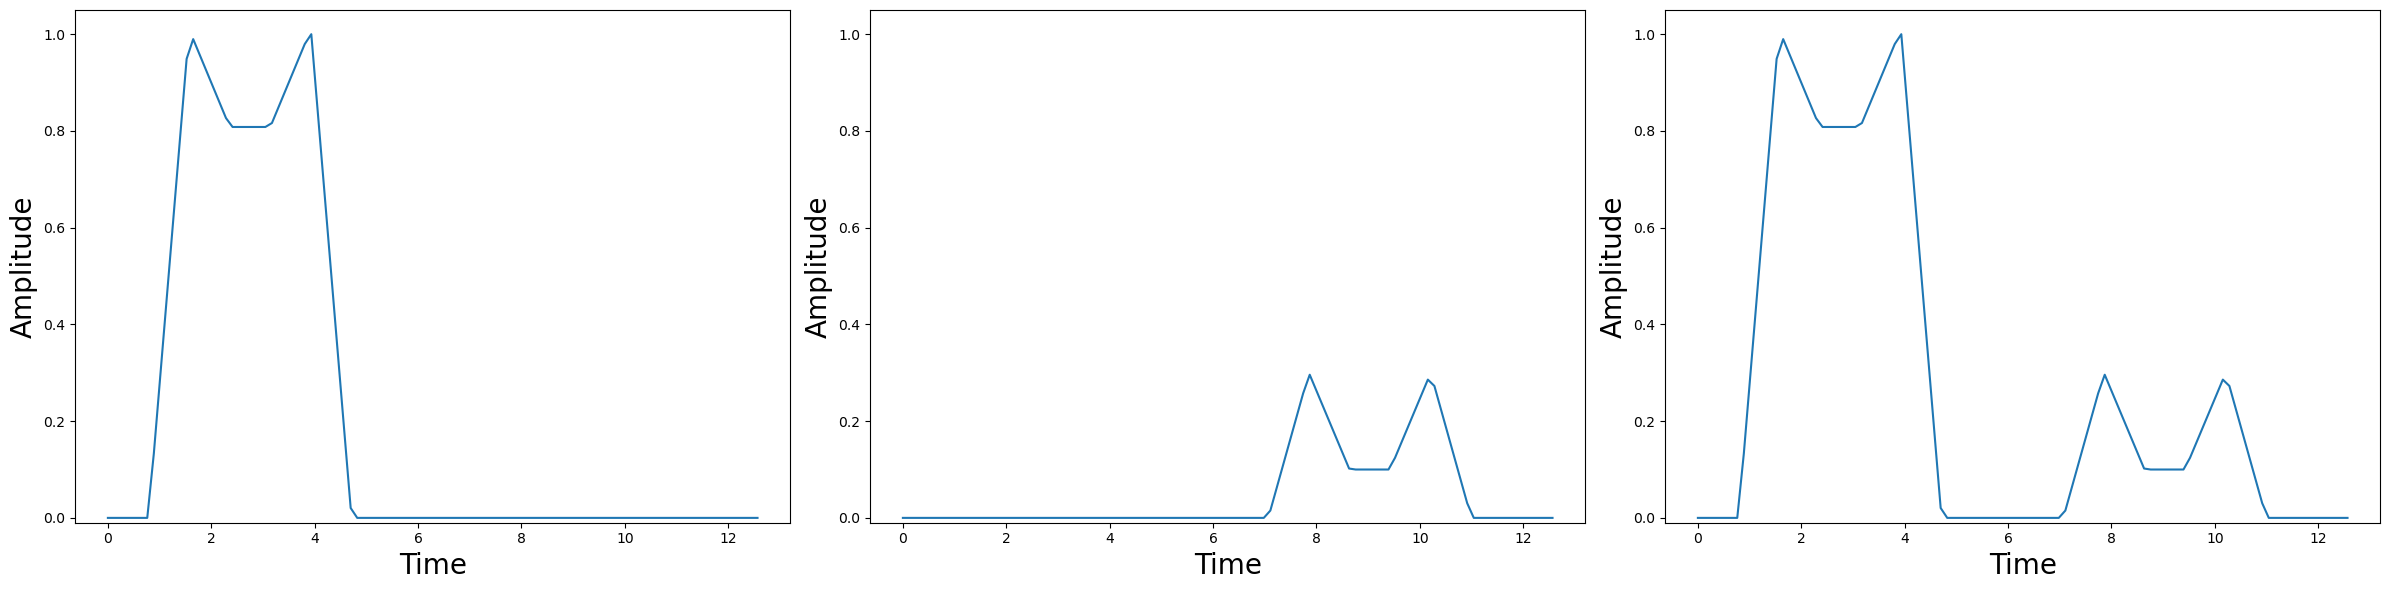

In [2]:
# Generate base signals and mix to form dataset

x_anchor = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0])
y_anchor = np.array([0.0, 0.0, 1.0, 0.8, 0.8, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# First base shape
a_smooth = np.linspace(x_anchor.min(), x_anchor.max(), 100)
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_1 = spline(a_smooth)
y_smooth_1 /= np.max(y_smooth_1)



# Second base shape
y_anchor = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.1, 0.1, 0.3, 0.0, 0.0, 0.0])
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_2 = spline(a_smooth)



# Mix two shapes to create dataset
np.random.seed(42)
rand = np.random.rand(3)

# Fixed dataset (no randomness)
X_list = [
    y_smooth_1,
    y_smooth_2,
    y_smooth_1 + y_smooth_2
]

# Plot
t = np.linspace(0, 4 * np.pi, 100)
plt.figure(figsize=(24, 6))

for i, signal in enumerate(X_list):
    plt.subplot(1, len(X_list), i + 1)
    plt.plot(t, signal)
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()
plt.show()

X = np.array(X_list)

# Run Top-NMF

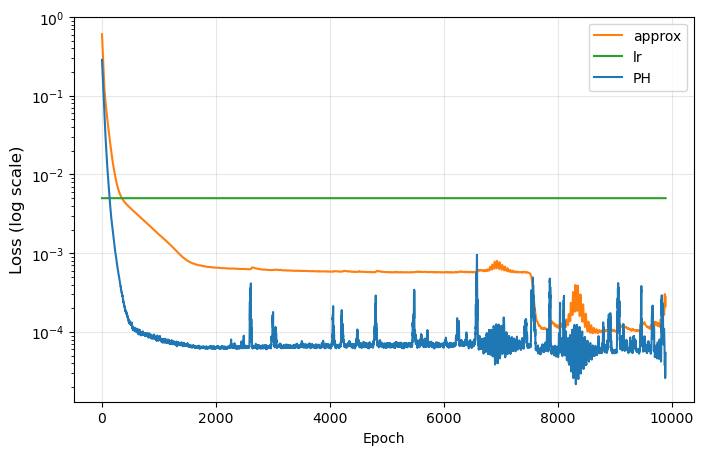

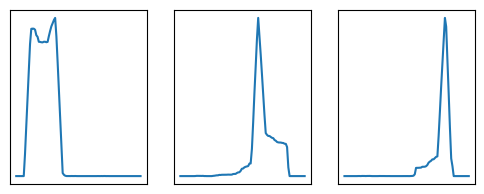

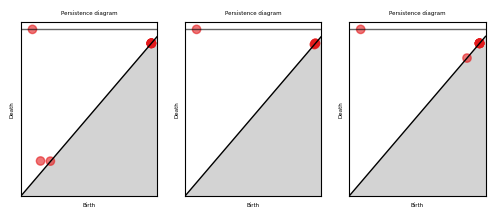

  0%|          | 0/10000 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  current = float(metrics)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


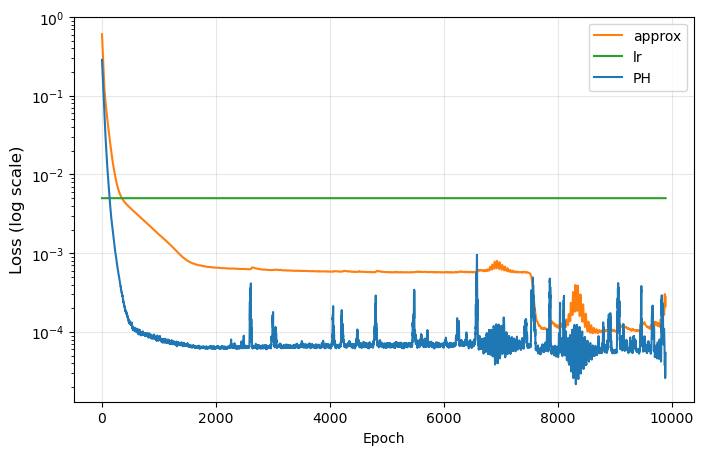

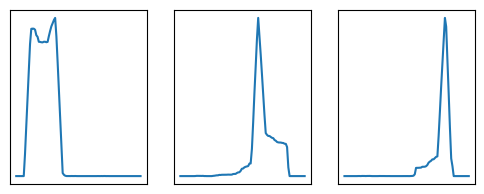

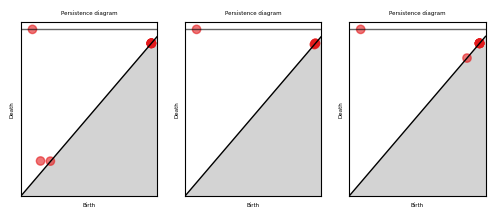

In [3]:
cubical_complex = CubicalComplex(
    superlevel=True,
    dim=len((X.shape[1],)),
    mode='V'
)


target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


model = TopologicalNMF(
    n_components=3,
    device='cpu',
    complex=cubical_complex,
    ph_loss_fn=weighted_persistence_loss,
    ph_loss_params={'remove_longest': False},
    data_shape=(X.shape[1],),
    use_embedding=False,
    random_state = 42
)

model.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_top=1.5,
    PH_dims=[0],
    start_epoch_topological=0,
    show_plots=['loss', 'basis', 'PH'],
    disp_interval=10,
    verbose=True,
    init_method = 'nndsvda',
    plot_grid = (1,3),
    target_diagrams = target_diagrams,
    superlevel=True,
    PHmode='V',
    normalize_V_max = True,
)
# plt.close('all')

In [5]:
model.W

tensor([[1.0119, 0.0000, 0.0000],
        [0.0000, 0.2822, 0.2281],
        [1.0320, 0.2807, 0.2282]])